
# Capstone Project | DETECTION OF FRAUD DATASETS

# Problem Statement:
As digital financial transactions increase globally, so does the sophisticated nature of financial fraud, costing institutions billions of dollars annually. The primary challenge in detecting these fraudulent activities is the highly imbalanced nature of transaction data—where legitimate transactions vastly outnumber fraudulent ones. Traditional rule-based systems often struggle to adapt to new fraud patterns and generate a high rate of false positives, which degrades customer experience.

# Objectives :

The objective of this capstone project is to develop a robust machine learning pipeline capable of accurately identifying fraudulent transactions. By leveraging advanced data preprocessing techniques, such as Synthetic Minority Over-sampling Technique (SMOTE), and utilizing tree-based classification algorithms, this project aims to build a predictive model that maximizes the recall of fraud detection while maintaining a precise understanding of normal transaction behavior.

# 📊 Financial Fraud Detection: End-to-End Machine Learning Pipeline

## Table of Contents
1. [Introduction & Problem Statement](#1-introduction)
2. [Dataset Overview & Loading](#2-dataset)
3. [Exploratory Data Analysis (EDA)](#3-eda)
4. [Data Preprocessing & Feature Engineering](#4-preprocessing)
5. [Train-Test Split (Avoiding Data Leakage)](#5-split)
6. [Handling Imbalanced Data using SMOTE](#6-smote)
7. [Model Building & Training](#7-modeling)
8. [Model Evaluation & Feature Importance](#8-evaluation)



In [2]:
#Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix


In [3]:
# Loading datasets
df = pd.read_csv("C:/Users/Akash Mahato/OneDrive/ドキュメント/Desktop/capstone folder/Fraud_Analysis_Dataset.csv")

In [4]:
# checking number of rows and column
df.shape 

(11142, 10)

In [5]:
# looking for datasets head
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud
0,1,TRANSFER,181.0,C1305486145,181.0,0.0,C553264065,0.0,0.0,1
1,1,CASH_OUT,181.0,C840083671,181.0,0.0,C38997010,21182.0,0.0,1
2,1,TRANSFER,2806.0,C1420196421,2806.0,0.0,C972765878,0.0,0.0,1
3,1,CASH_OUT,2806.0,C2101527076,2806.0,0.0,C1007251739,26202.0,0.0,1
4,1,TRANSFER,20128.0,C137533655,20128.0,0.0,C1848415041,0.0,0.0,1


In [6]:
# looking for datasets tail
df.tail()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud
11137,7,DEBIT,6393.71,C1331144930,433084.38,426690.68,C684896216,478421.00,210535.25,0
11138,7,CASH_OUT,298799.54,C932023579,426690.68,127891.14,C1761353343,704355.36,5270364.19,0
11139,7,CASH_OUT,423159.63,C61395726,127891.14,0.00,C1298316171,610479.00,749621.53,0
11140,7,PAYMENT,1094.03,C1224570697,13918.00,12823.97,M983553548,0.00,0.00,0
11141,7,PAYMENT,9235.58,C1637966097,39963.00,30727.42,M609545864,0.00,0.00,0


In [7]:
df.rename(columns={'isFraud': 'Fraud'}, inplace=True)

In [8]:
# Checking the basic imformation of a datasets
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11142 entries, 0 to 11141
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   step            11142 non-null  int64  
 1   type            11142 non-null  object 
 2   amount          11142 non-null  float64
 3   nameOrig        11142 non-null  object 
 4   oldbalanceOrg   11142 non-null  float64
 5   newbalanceOrig  11142 non-null  float64
 6   nameDest        11142 non-null  object 
 7   oldbalanceDest  11142 non-null  float64
 8   newbalanceDest  11142 non-null  float64
 9   Fraud           11142 non-null  int64  
dtypes: float64(5), int64(2), object(3)
memory usage: 870.6+ KB


In [9]:
# Checking the null values in a datasets
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
Fraud             0
dtype: int64

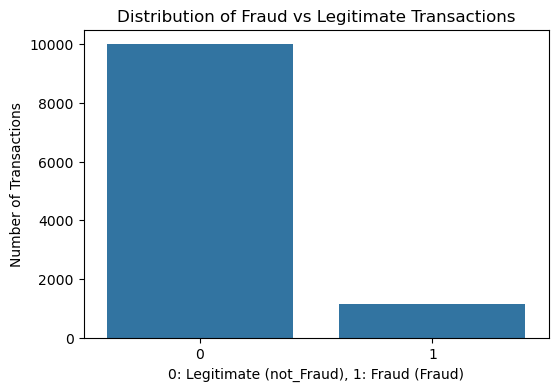

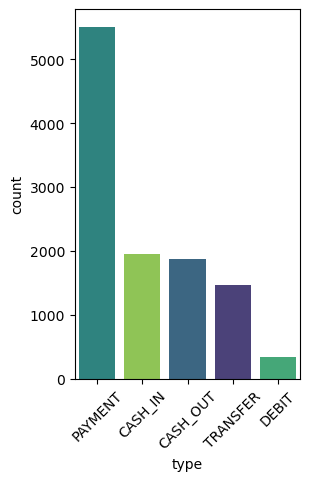


--- Fraud by Transaction Type ---
type
CASH_IN       0
CASH_OUT    578
DEBIT         0
PAYMENT       0
TRANSFER    564
Name: Fraud, dtype: int64


In [25]:
# Targets Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='Fraud', data=df)
plt.title('Distribution of Fraud vs Legitimate Transactions')
plt.xlabel('0: Legitimate (not_Fraud), 1: Fraud (Fraud)')
plt.ylabel('Number of Transactions')
plt.show()

# Plot 2: Transaction Types
plt.subplot(1, 2, 2)
sns.countplot(
    data=df,
    x='type',
    hue='type',   # 👈 add this
    palette='viridis',
    order=df['type'].value_counts().index,
    legend=False  # 👈 remove duplicate legend
)
plt.xticks(rotation=45)
plt.show()

# Observe Fraud by Transaction Type
print("\n--- Fraud by Transaction Type ---")
print(df.groupby('type')['Fraud'].sum())



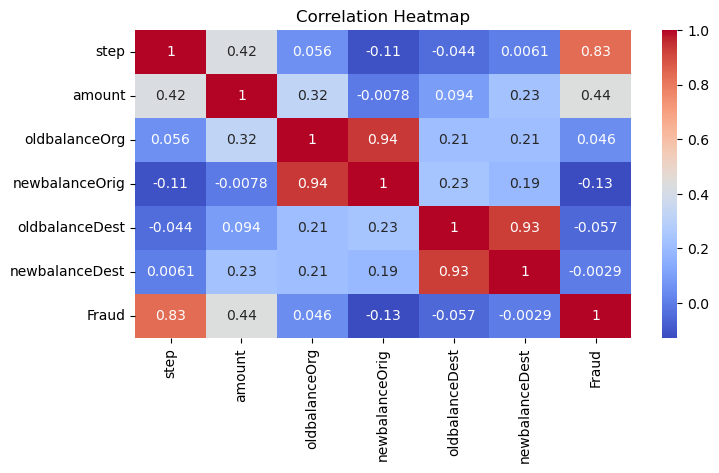

In [27]:
# Corelation Heatmap (numeric only)
plt.figure(figsize=(8,4))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# 3. FEATURE ENGINEERING

In [28]:
# Encode categorical variables
from sklearn.preprocessing import LabelEncoder, StandardScaler
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])


In [29]:
# Split features and target
X = df.drop('Fraud', axis=1)
y = df['Fraud']


In [30]:
# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [31]:
# 1. Preprocess the data (Drop IDs and convert text to numbers)
df_clean = df.drop(['nameOrig', 'nameDest', 'step'], axis=1)
df_clean = pd.get_dummies(df_clean, columns=['type'], drop_first=True)

# 2. Separate Features (X) and Target (y)
X = df_clean.drop('Fraud', axis=1)
y = df_clean['Fraud']

# 3. Create X_train and y_train FIRST (Train-Test Split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=24, stratify=y)

# 4. NOW apply SMOTE to the training data
smote = SMOTE(random_state=24)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# 5. Verify it worked
print("✅ Success! SMOTE applied correctly.")
print("Before SMOTE, training data size:", X_train.shape)
print("After SMOTE, training data size:", X_train_smote.shape)
print("\nBalanced Class counts after SMOTE:")
print(y_train_smote.value_counts())




✅ Success! SMOTE applied correctly.
Before SMOTE, training data size: (7799, 9)
After SMOTE, training data size: (14000, 9)

Balanced Class counts after SMOTE:
Fraud
0    7000
1    7000
Name: count, dtype: int64


# 4. TRAIN-TEST SPLIT

In [32]:
# Import the train_test_split function from scikit-learn
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=24)

# 5. MODEL TRAINING

In [33]:
# Import the required models from scikit-learn
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, roc_auc_score

models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier()
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    print(f"\nModel: {name}")
    print(classification_report(y_test, y_pred))

    roc = roc_auc_score(y_test, y_prob)
    print("ROC-AUC:", roc)

    results[name] = {
        "model": model,
        "roc": roc
    }



Model: Logistic Regression
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      3009
           1       1.00      0.89      0.94       334

    accuracy                           0.99      3343
   macro avg       0.99      0.94      0.97      3343
weighted avg       0.99      0.99      0.99      3343

ROC-AUC: 0.991764228273264

Model: Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3009
           1       1.00      0.98      0.99       334

    accuracy                           1.00      3343
   macro avg       1.00      0.99      0.99      3343
weighted avg       1.00      1.00      1.00      3343

ROC-AUC: 0.9999462689774986

Model: Gradient Boosting
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3009
           1       1.00      0.98      0.99       334

    accuracy                           1.00      33

# 6. BEST MODEL SELECTION

In [34]:
best_model_name = max(results, key=lambda x: results[x]['roc'])
best_model = results[best_model_name]['model']

print("\nBest Model:", best_model_name)


Best Model: Random Forest


# 7. FINANCIAL IMPACT ANALYSIS

In [35]:
# Assumptions (you can modify)
transaction_amount = 5000
fraud_loss = 5000
false_positive_cost = 50


In [37]:
# Predictions
y_pred = best_model.predict(X_test)

TP = np.sum((y_test == 1) & (y_pred == 1))
FP = np.sum((y_test == 0) & (y_pred == 1))
FN = np.sum((y_test == 1) & (y_pred == 0))
TN = np.sum((y_test == 0) & (y_pred == 0))

# Financial metrics
revenue_saved = TP * fraud_loss
loss_due_to_missed_fraud = FN * fraud_loss
cost_false_alert = FP * false_positive_cost

profit = revenue_saved - loss_due_to_missed_fraud - cost_false_alert

print("\nFinancial Analysis:")
print("Revenue Saved:", revenue_saved)
print("Loss (Missed Fraud):", loss_due_to_missed_fraud)
print("False Alert Cost:", cost_false_alert)
print("Net Profit:", profit)


Financial Analysis:
Revenue Saved: 1640000
Loss (Missed Fraud): 30000
False Alert Cost: 0
Net Profit: 1610000


# 8. VISUALIZATION OF MODEL PERFORMANCE

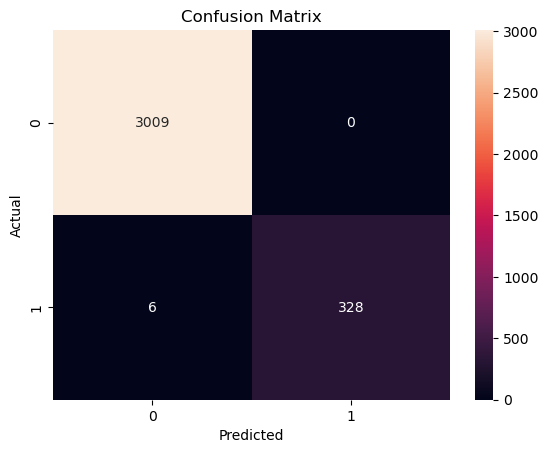

In [38]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

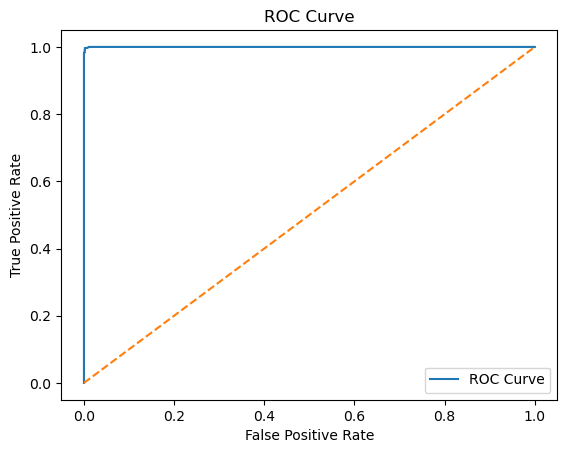

In [43]:
# ROC Curve
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, best_model.predict_proba(X_test)[:,1])

plt.figure()
plt.plot(fpr, tpr, label='ROC Curve')
plt.plot([0,1],[0,1],'--')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()